In [1]:
import pandas as pd
import os
import numpy as np
import shap
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from pandas.api.types import is_datetime64_any_dtype
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix

/Users/manjakaranjatoson/anaconda3/envs/env_ppml/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
df = pd.read_csv("/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PROJECTS/CDSD/PPML/data/processed/test_philippe/SignofFlightsDataset_20260409_023340_CLEAN.csv")
print(df.shape)
df.head()

(85375, 95)


/var/folders/p7/7w66qcfn4yj82k3sbs5fp74h0000gn/T/ipykernel_75276/178990422.py:1: DtypeWarning: Columns (64,65,67,75,77,79,81,83,85) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PROJECTS/CDSD/PPML/data/processed/test_philippe/SignofFlightsDataset_20260409_023340_CLEAN.csv")


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-09 02:34:49,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2025-10-11,2025-10-11,5O 701,ASL Airlines France,CDG,MRS,NaN,NaN,2025-10-11 01:39+02:00,2025-10-11 02:34+02:00,...,NaN,616.0,620.0,1236.0,0.0,119.0,113.0,232.0,1.0,0.0
2,2025-10-11,2025-10-11,AF 6001,Air France,MRS,ORY,1,2,2025-10-11 06:20+02:00,2025-10-11 07:45+02:00,...,NaN,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
3,2025-10-11,2025-10-11,AF 6004,Air France,ORY,MRS,3,1,2025-10-11 09:00+02:00,2025-10-11 10:20+02:00,...,NaN,299.0,299.0,598.0,0.0,119.0,113.0,232.0,1.0,0.0
4,2025-10-11,2025-10-11,AF 6009,Air France,MRS,ORY,1,2,2025-10-11 15:40+02:00,2025-10-11 17:05+02:00,...,NaN,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0


In [3]:
df.columns

Index(['flight_date', 'movement_date', 'flight_number', 'airline',
       'airport_origin', 'airport_destination', 'terminal_departure',
       'terminal_arrival', 'scheduled_departure', 'scheduled_arrival',
       'estimated_departure', 'estimated_arrival', 'actual_departure',
       'actual_arrival', 'actual_source_departure', 'actual_source_arrival',
       'departure_delay_min', 'departure_advance_min', 'arrival_delay_min',
       'arrival_advance_min', 'status', 'movement_type', 'time_dep',
       'relative_humidity_2m_dep', 'dew_point_dep', 'icing_conditions_dep',
       'rain_dep', 'freezing_rain_dep', 'snow_dep', 'thunderstorms_dep',
       'pressure_msl_dep', 'wind_shear_dep', 'wind_gusts_10m_dep',
       'wind_speed_10m_dep', 'wind_direction_10m_dep', 'precipitation_dep',
       'has_precipitation_dep', 'fog_dep', 'humidity_dep',
       'temperature_2m_dep', 'cloud_cover_dep', 'cloud_base_dep',
       'visibility_dep', 'time_arr', 'relative_humidity_2m_arr',
       'dew_point

# 1. EDA, Data cleaning, feature engineering

### Supressing first line

In [4]:
print(df.iloc[0])
df = df.iloc[1:].reset_index(drop=True)

display(df.head())

flight_date                             DATE_GENERATION
movement_date                       2026-04-09 02:34:49
flight_number                                       NaN
airline                                             NaN
airport_origin                                      NaN
                                           ...         
nombre_departs_destination                          NaN
nombre_arrivees_destination                         NaN
somme_depart_arrivee_destination                    NaN
congestion_destination                              NaN
retard arrivée                                      NaN
Name: 0, Length: 95, dtype: object


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-10-11,2025-10-11,5O 701,ASL Airlines France,CDG,MRS,NaN,NaN,2025-10-11 01:39+02:00,2025-10-11 02:34+02:00,...,NaN,616.0,620.0,1236.0,0.0,119.0,113.0,232.0,1.0,0.0
1,2025-10-11,2025-10-11,AF 6001,Air France,MRS,ORY,1,2,2025-10-11 06:20+02:00,2025-10-11 07:45+02:00,...,NaN,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
2,2025-10-11,2025-10-11,AF 6004,Air France,ORY,MRS,3,1,2025-10-11 09:00+02:00,2025-10-11 10:20+02:00,...,NaN,299.0,299.0,598.0,0.0,119.0,113.0,232.0,1.0,0.0
3,2025-10-11,2025-10-11,AF 6009,Air France,MRS,ORY,1,2,2025-10-11 15:40+02:00,2025-10-11 17:05+02:00,...,NaN,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
4,2025-10-11,2025-10-11,AF 6101,Air France,TLS,ORY,NaN,2,2025-10-11 06:30+02:00,2025-10-11 07:55+02:00,...,NaN,78.0,73.0,151.0,0.0,299.0,299.0,598.0,0.0,0.0


### Filtering to domestic flights

In [5]:
df["airport_destination"].value_counts()

airport_destination
CDG    36832
NCE    11816
TLS    11051
LYS    10054
MRS     8816
ORY     6805
Name: count, dtype: int64

### Duplicates

In [6]:
df[df.duplicated(subset=["flight_number", "flight_date"], keep=False)]

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
177,2025-10-12,2025-10-12,AF 7303,Air France,NCE,CDG,2,NaN,2025-10-12 11:05+02:00,NaN,...,NaN,177.0,180.0,357.0,1.0,643.0,631.0,1274.0,0.0,0.0
178,2025-10-12,2025-10-12,AF 7303,Air France,NCE,CDG,NaN,2F,NaN,2025-10-12 12:40+02:00,...,NaN,177.0,180.0,357.0,1.0,643.0,631.0,1274.0,0.0,0.0
696,2025-10-15,2025-10-15,AF 7419,Air France,TLS,CDG,NaN,NaN,2025-10-15 07:30+02:00,NaN,...,NaN,99.0,96.0,195.0,1.0,624.0,565.0,1189.0,0.0,1.0
697,2025-10-15,2025-10-15,AF 7419,Air France,TLS,CDG,NaN,2F,NaN,2025-10-15 09:00+02:00,...,NaN,99.0,96.0,195.0,1.0,624.0,565.0,1189.0,0.0,0.0
944,2025-10-16,2025-10-16,WT 6RS,Swiftair,MRS,CDG,NaN,NaN,2025-10-16 22:18+02:00,NaN,...,NaN,139.0,145.0,284.0,1.0,637.0,645.0,1282.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85165,2026-04-08,2026-04-08,MU 1512,China Eastern,LYS,CDG,1,2F,2026-04-08 14:40+02:00,2026-04-08 15:50+02:00,...,NaN,230.0,235.0,465.0,1.0,2443.0,2467.0,4910.0,1.0,0.0
85173,2026-04-08,2026-04-08,MU 1531,China Eastern,CDG,MRS,2F,1,2026-04-08 09:55+02:00,2026-04-08 11:15+02:00,...,NaN,2443.0,2467.0,4910.0,1.0,126.0,125.0,251.0,1.0,0.0
85174,2026-04-08,2026-04-08,MU 1531,China Eastern,CDG,MRS,2F,1,2026-04-08 21:25+02:00,2026-04-08 22:50+02:00,...,NaN,2443.0,2467.0,4910.0,1.0,126.0,125.0,251.0,1.0,0.0
85184,2026-04-08,2026-04-08,MU 1768,China Eastern,LYS,CDG,1,NaN,2026-04-08 10:20+02:00,NaN,...,NaN,230.0,235.0,465.0,1.0,2443.0,2467.0,4910.0,1.0,0.0


##### Cas 1 : Drop all duplicates

In [7]:
df_1 = df.drop_duplicates(subset=["flight_number", "flight_date"], keep=False)
# Verif duplicates bien DROPED
df_1[df_1.duplicated(subset=["flight_number", "flight_date"], keep=False)]

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée


#### Cas 2 : Smart merge duplicates

Nous avons identifié que les doublons apparents ne correspondent pas à des escales, mais à deux lignes complémentaires décrivant un même vol : l’une pour le départ et l’autre pour l’arrivée. Il ne faut donc pas supprimer ces lignes ni les traiter séparément, car cela entraînerait une perte d’information et un biais dans le modèle. La bonne approche consiste à regrouper ces lignes pour reconstruire un vol complet en une seule observation, en combinant les informations de départ et d’arrivée (par exemple via un groupby et des agrégations adaptées).


In [8]:
dup_mask = df.duplicated(
    subset=["flight_number", "flight_date",  "airport_origin", "airport_destination"],
    keep=False
)
df_dups = df[dup_mask]
df_clean = df[~dup_mask]

df_dups["movement_type"].value_counts()

movement_type
arrival      690
departure    676
Name: count, dtype: int64

In [9]:
# --- 1) copie
df_3 = df_dups.copy()

# on garde l'ordre exact des colonnes d'origine
original_cols = df_3.columns.tolist()

# --- 2) conversion datetime
datetime_cols = [
    "flight_date",
    "movement_date",
    "scheduled_departure",
    "scheduled_arrival",
    "estimated_departure",
    "estimated_arrival",
    "actual_departure",
    "actual_arrival",
    "actual_source_departure",
    "actual_source_arrival",
]

for col in datetime_cols:
    if col in df_3.columns:
        df_3[col] = pd.to_datetime(df_3[col], errors="coerce", utc=True)

# --- 3) séparation départ / arrivée
df_dep = df_3[df_3["movement_type"] == "departure"].copy()
df_arr = df_3[df_3["movement_type"] == "arrival"].copy()

# --- 4) clé logique
keys = ["flight_number", "flight_date", "airport_origin", "airport_destination"]

# --- 5) tri
df_dep = df_dep.sort_values(keys + ["scheduled_departure", "estimated_departure", "actual_departure"])
df_arr = df_arr.sort_values(keys + ["scheduled_arrival", "estimated_arrival", "actual_arrival"])

# --- 6) occurrence pour distinguer les multi-vols même jour
df_dep["occurrence"] = df_dep.groupby(keys).cumcount()
df_arr["occurrence"] = df_arr.groupby(keys).cumcount()

# --- 7) merge avec TOUTES les colonnes
df_merge_raw = df_dep.merge(
    df_arr,
    on=keys + ["occurrence"],
    how="left",
    suffixes=("_dep_side", "_arr_side"),
    validate="1:1"
)

# --- 8) reconstruction des colonnes d'origine
df_merged = pd.DataFrame()

for col in original_cols:
    dep_col = f"{col}_dep_side"
    arr_col = f"{col}_arr_side"
    
    if dep_col in df_merge_raw.columns and arr_col in df_merge_raw.columns:
        # on prend d'abord la valeur côté départ, sinon côté arrivée
        df_merged[col] = df_merge_raw[dep_col].combine_first(df_merge_raw[arr_col])
    elif dep_col in df_merge_raw.columns:
        df_merged[col] = df_merge_raw[dep_col]
    elif arr_col in df_merge_raw.columns:
        df_merged[col] = df_merge_raw[arr_col]
    elif col in df_merge_raw.columns:
        # cas des colonnes de jointure
        df_merged[col] = df_merge_raw[col]

# on remet exactement l'ordre d'origine
df_merged = df_merged[original_cols].reset_index(drop=True)

print(df_dep.shape)
print(df_arr.shape)
print(df_merged.shape)
print()

display(f"HEAD of DF_MERGED :", df_merged.head())
print()

print("Check if still any duplicates")
df_merged[df_merged.duplicated(
    subset=[
        "flight_number",
        "flight_date",
        "airport_origin",
        "airport_destination",
        "scheduled_departure"
    ],
    keep=False
)]

(676, 96)
(690, 96)
(676, 95)



'HEAD of DF_MERGED :'

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-11-23 00:00:00+00:00,2025-11-23 00:00:00+00:00,AF 6110,Air France,ORY,TLS,3,NaN,2025-11-23 11:00:00+00:00,2025-11-23 12:15:00+00:00,...,NaN,437.0,447.0,884.0,0.0,77.0,79.0,156.0,0.0,0.0
1,2025-11-23 00:00:00+00:00,2025-11-23 00:00:00+00:00,AF 6116,Air France,ORY,TLS,3,NaN,2025-11-23 15:10:00+00:00,2025-11-23 16:20:00+00:00,...,NaN,437.0,447.0,884.0,0.0,77.0,79.0,156.0,0.0,1.0
2,2025-11-15 00:00:00+00:00,2025-11-15 00:00:00+00:00,AF 6201,Air France,NCE,ORY,2,2,2025-11-15 05:45:00+00:00,2025-11-15 07:15:00+00:00,...,NaN,95.0,93.0,188.0,0.0,235.0,237.0,472.0,0.0,1.0
3,2025-10-12 00:00:00+00:00,2025-10-12 00:00:00+00:00,AF 7303,Air France,NCE,CDG,2,2F,2025-10-12 09:05:00+00:00,2025-10-12 10:40:00+00:00,...,NaN,177.0,180.0,357.0,1.0,643.0,631.0,1274.0,0.0,0.0
4,2025-10-23 00:00:00+00:00,2025-10-23 00:00:00+00:00,AF 7323,Air France,NCE,CDG,2,2F,2025-10-23 11:55:00+00:00,2025-10-23 13:30:00+00:00,...,NaN,174.0,175.0,349.0,1.0,673.0,637.0,1310.0,0.0,1.0



Check if still any duplicates


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée


Good ! Nous pouvons supposer que les duplicates (arrivés et départ) ont été correctement mergés. 

In [10]:
# Concat df_merged with df_clean cf. See cell 41
df_2 = pd.concat([df_clean, df_merged], ignore_index=True)

print(df_2.shape)
print(df_clean.shape)
print(df_merged.shape)

(84684, 95)
(84008, 95)
(676, 95)


### NaN Values

In [11]:
(df_1.isna().mean() * 100).sort_values(ascending=False)

visibility_arr    100.000000
cloud_base_arr    100.000000
visibility_dep    100.000000
cloud_base_dep    100.000000
LABEL_CDG          99.384143
                     ...    
Vacances NCE        0.000000
Vacances TLS        0.000000
Vacances MRS        0.000000
Vacances LYS        0.000000
retard arrivée      0.000000
Length: 95, dtype: float64

#### Ceci est une fonction pour drop les nan selon le pourcentage de nan dans la colonne (via threshold)

In [12]:
def nan_drop(dataframe):
    na_pct = dataframe.isna().mean() * 100

    # seuil
    threshold = 65

    # colonnes à drop
    cols_to_drop = na_pct[na_pct > threshold].index.tolist()

    print("Colonnes supprimées :", cols_to_drop)

    # drop
    dataframe = dataframe.drop(columns=cols_to_drop)

    # check
    print(dataframe.shape)

    return dataframe

In [13]:
df_1 = nan_drop(df_1)

Colonnes supprimées : ['cloud_base_dep', 'visibility_dep', 'cloud_base_arr', 'visibility_arr', 'Vacances Scolaires', 'Label des Vacances', 'Label Jour Ferié', 'LABEL_LYON', 'LABEL_TOULOUSE', 'LABEL_NICE', 'LABEL_MARSEILLE', 'LABEL_CDG', 'LABEL_ORLY']
(83948, 82)


In [14]:
df_2 = nan_drop(df_2)

Colonnes supprimées : ['cloud_base_dep', 'visibility_dep', 'cloud_base_arr', 'visibility_arr', 'Vacances Scolaires', 'Label des Vacances', 'Label Jour Ferié', 'LABEL_LYON', 'LABEL_TOULOUSE', 'LABEL_NICE', 'LABEL_MARSEILLE', 'LABEL_CDG', 'LABEL_ORLY']
(84684, 82)


### Traitement data leakage (ces colonnes qui ne sont pas des targets et qui peuvent faire tricher le modèle)

**On fait le choix de garder arrival_delay_min comme target y**

Donc on drop les colonnes : 

Edit  : J’ai testé la présence de variables potentiellement fuyantes (estimated times), leur suppression n’a pas impacté significativement les performances → modèle robuste et sans leakage majeur

**AVANT :**

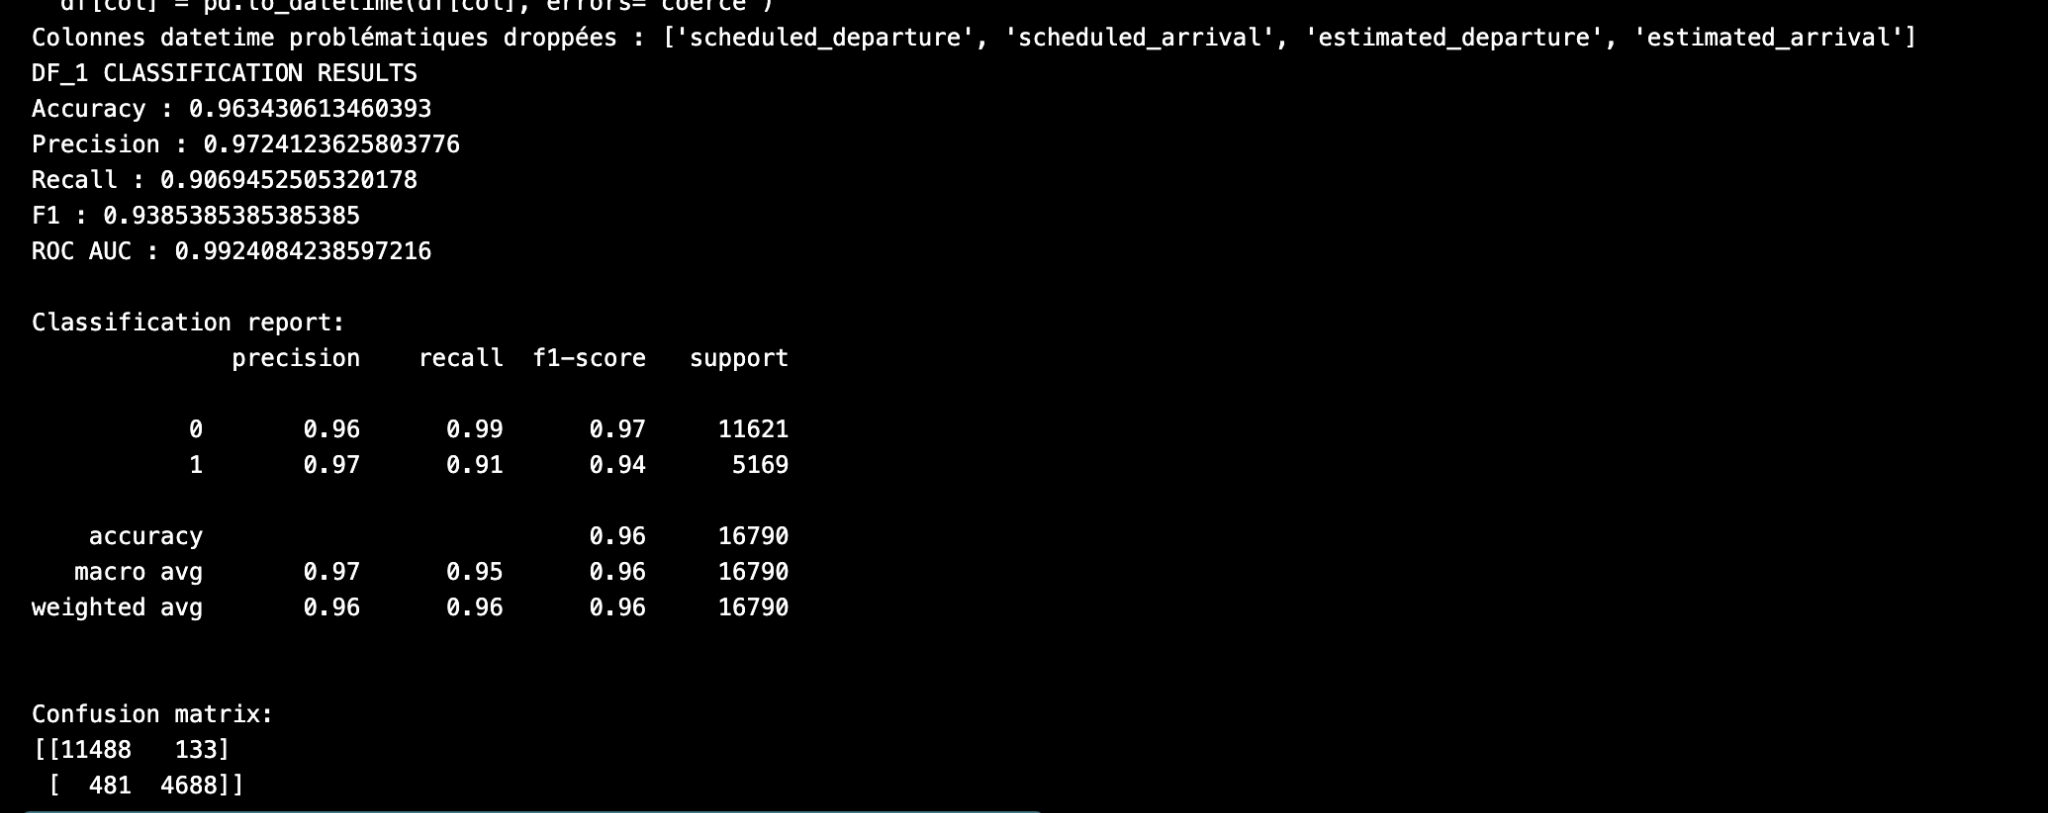

**APRES**

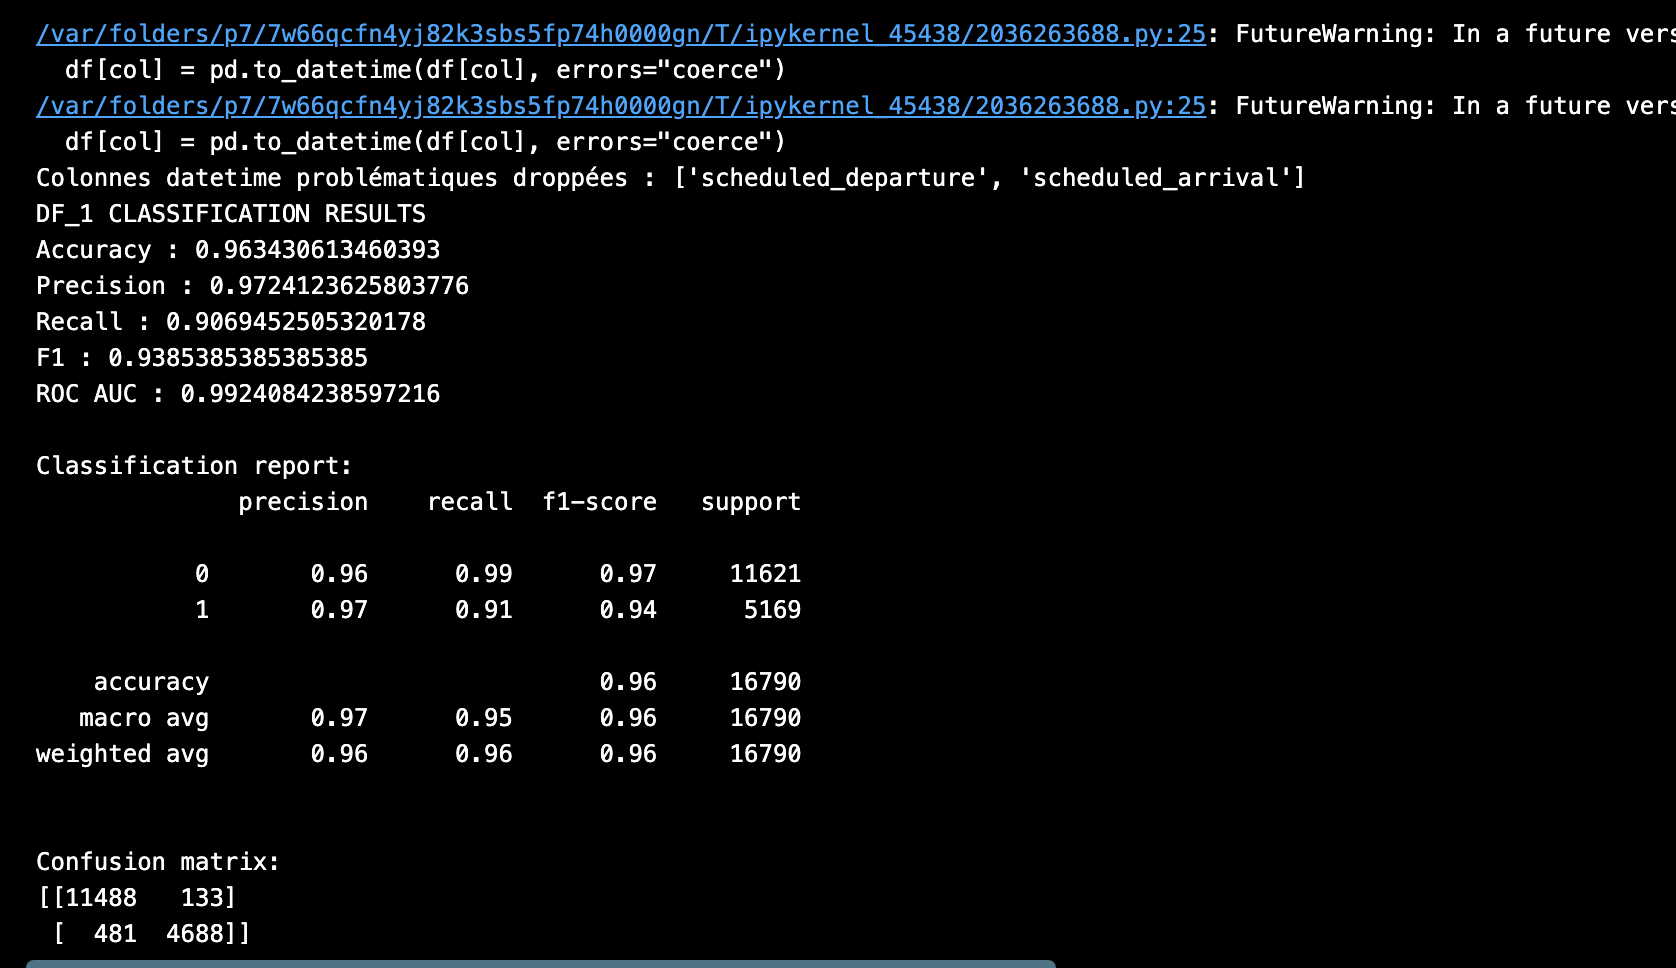

In [15]:
df_1 = df_1.drop(columns=[
    "actual_arrival",
    "actual_departure",
    "actual_source_arrival",
    "actual_source_departure",
    # "arrival_advance_min", pour le test de Caboostregressor
    "departure_delay_min",
    "departure_advance_min",
    "estimated_departure",
    "estimated_arrival"
])

df_2 = df_2.drop(columns=[
    "actual_arrival",
    "actual_departure",
    "actual_source_arrival",
    "actual_source_departure",
    "arrival_advance_min",
    "departure_delay_min",
    "estimated_arrival"
])

#### Traitements des NaN faibles > 15%

In [16]:
# arrival_delay_min / Est-ce vols annulés ? infos d'arrivée non remontées ? (on display que df_1 car le % de NaN entre df_1 et df_2 sont =)

display(df_1[df_1["arrival_delay_min"].isna()][
    ["status", "scheduled_arrival", "airport_origin", "airport_destination"]
].head(20))

# Les NaN sont des vols en cours ("approaching") ou pas encore arrivés. 
# Donc nous pouvons les exclure pour le train et les garder pour le test (vrai simulation avec données en temps réel - incomplètes)

# Nous ferons donc ces traitements après SPLIT de X et Y



,status,scheduled_arrival,airport_origin,airport_destination
158,Approaching,2025-10-11 02:38+02:00,CDG,MRS
330,Approaching,2025-10-13 23:58+02:00,MRS,CDG
331,Approaching,2025-10-13 23:58+02:00,LYS,CDG
948,Approaching,2025-10-17 05:43+02:00,CDG,LYS
1004,Approaching,2025-10-17 22:30+02:00,CDG,TLS
1101,Approaching,2025-10-17 00:26+02:00,TLS,CDG
1103,Approaching,2025-10-18 02:35+02:00,CDG,MRS
1238,Approaching,2025-10-18 02:38+02:00,CDG,MRS
1591,Approaching,2025-10-21 14:10+02:00,NCE,CDG
2011,Delayed,2025-10-23 22:00+02:00,CDG,LYS


### RECAP datasets train qu'on a df_1 & df_2

In [17]:
print(f"df_1 with droped duplicates : ", df_1.shape) 
display(df_1.head()) 
print() 
print(f"df_2 with merged duplicates : ", df_2.shape) 
display(df_2.head())

df_1 with droped duplicates :  (83948, 74)


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,GREVE_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-10-11,2025-10-11,5O 701,ASL Airlines France,CDG,MRS,NaN,NaN,2025-10-11 01:39+02:00,2025-10-11 02:34+02:00,...,Non,616.0,620.0,1236.0,0.0,119.0,113.0,232.0,1.0,0.0
1,2025-10-11,2025-10-11,AF 6001,Air France,MRS,ORY,1,2,2025-10-11 06:20+02:00,2025-10-11 07:45+02:00,...,Non,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
2,2025-10-11,2025-10-11,AF 6004,Air France,ORY,MRS,3,1,2025-10-11 09:00+02:00,2025-10-11 10:20+02:00,...,Non,299.0,299.0,598.0,0.0,119.0,113.0,232.0,1.0,0.0
3,2025-10-11,2025-10-11,AF 6009,Air France,MRS,ORY,1,2,2025-10-11 15:40+02:00,2025-10-11 17:05+02:00,...,Non,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
4,2025-10-11,2025-10-11,AF 6101,Air France,TLS,ORY,NaN,2,2025-10-11 06:30+02:00,2025-10-11 07:55+02:00,...,Non,78.0,73.0,151.0,0.0,299.0,299.0,598.0,0.0,0.0



df_2 with merged duplicates :  (84684, 75)


,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,GREVE_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,2025-10-11,2025-10-11,5O 701,ASL Airlines France,CDG,MRS,NaN,NaN,2025-10-11 01:39+02:00,2025-10-11 02:34+02:00,...,Non,616.0,620.0,1236.0,0.0,119.0,113.0,232.0,1.0,0.0
1,2025-10-11,2025-10-11,AF 6001,Air France,MRS,ORY,1,2,2025-10-11 06:20+02:00,2025-10-11 07:45+02:00,...,Non,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
2,2025-10-11,2025-10-11,AF 6004,Air France,ORY,MRS,3,1,2025-10-11 09:00+02:00,2025-10-11 10:20+02:00,...,Non,299.0,299.0,598.0,0.0,119.0,113.0,232.0,1.0,0.0
3,2025-10-11,2025-10-11,AF 6009,Air France,MRS,ORY,1,2,2025-10-11 15:40+02:00,2025-10-11 17:05+02:00,...,Non,119.0,113.0,232.0,1.0,299.0,299.0,598.0,0.0,0.0
4,2025-10-11,2025-10-11,AF 6101,Air France,TLS,ORY,NaN,2,2025-10-11 06:30+02:00,2025-10-11 07:55+02:00,...,Non,78.0,73.0,151.0,0.0,299.0,299.0,598.0,0.0,0.0


#### Filtering the targets

In [18]:
df_1["retard arrivée"] = (df_1["arrival_delay_min"] > 15).astype(int)
df_2["retard arrivée"] = (df_2["arrival_delay_min"] > 15).astype(int)


In [19]:
display(df_1.shape)
display(df_2.shape)

(83948, 74)

(84684, 75)

# 2. MODELING

### 2.1. Classification

In [20]:
import mlflow
from dotenv import load_dotenv
import os

load_dotenv()

MLFLOW_TRACKING_URI = os.getenv("MLFLOW_TRACKING_URI")

mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("PPML_FlyOnTime")

print("Tracking URI:", mlflow.get_tracking_uri())

Tracking URI: https://stoneray-ppml-mlflow.hf.space


#### df_1 -> dataset drop duplicates

In [21]:
df_1_train = df_1[df_1["retard arrivée"].notna()].copy()

y_1 = df_1_train["retard arrivée"].astype(int)

X_1 = df_1_train.drop(columns=[
    "retard arrivée",
    "arrival_delay_min",
], errors="ignore")

datetime_cols = [
    "flight_date",
    "movement_date",
    "scheduled_departure",
    "scheduled_arrival",
    "time_dep",
    "time_arr"
]

def add_datetime_features_safe(df, datetime_cols):
    df = df.copy()
    bad_datetime_cols = []

    for col in datetime_cols:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors="coerce")

            if not is_datetime64_any_dtype(df[col]):
                bad_datetime_cols.append(col)

    usable_datetime_cols = [col for col in datetime_cols if col in df.columns and col not in bad_datetime_cols]

    if "flight_date" in usable_datetime_cols:
        df["flight_month"] = df["flight_date"].dt.month
        df["flight_day"] = df["flight_date"].dt.day
        df["flight_dayofweek"] = df["flight_date"].dt.dayofweek

    if "scheduled_departure" in usable_datetime_cols:
        df["sched_dep_hour"] = df["scheduled_departure"].dt.hour
        df["sched_dep_minute"] = df["scheduled_departure"].dt.minute

    if "scheduled_arrival" in usable_datetime_cols:
        df["sched_arr_hour"] = df["scheduled_arrival"].dt.hour
        df["sched_arr_minute"] = df["scheduled_arrival"].dt.minute

    print("Colonnes datetime problématiques droppées :", bad_datetime_cols)

    df = df.drop(columns=datetime_cols, errors="ignore")

    return df

X_1 = add_datetime_features_safe(X_1, datetime_cols)

num_cols_1 = X_1.select_dtypes(include=["number"]).columns.tolist()
cat_cols_1 = X_1.select_dtypes(include=["object", "category", "bool"]).columns.tolist()

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor_1 = ColumnTransformer([
    ("num", num_pipeline, num_cols_1),
    ("cat", cat_pipeline, cat_cols_1)
])

model_1 = Pipeline([
    ("preprocessor", preprocessor_1),
    ("classifier", RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1,
        class_weight="balanced"
    )) # pour limiter random forest mettre min_sample_leaf et min_sample_split
])

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(
    X_1,
    y_1,
    test_size=0.2,
    random_state=42,
    stratify=y_1
)

model_1.fit(X_train_1, y_train_1)

y_pred_1 = model_1.predict(X_test_1)
y_proba_1 = model_1.predict_proba(X_test_1)[:, 1]

print("DF_1 CLASSIFICATION RESULTS")
print("Accuracy :", accuracy_score(y_test_1, y_pred_1))
print("Precision :", precision_score(y_test_1, y_pred_1, zero_division=0))
print("Recall :", recall_score(y_test_1, y_pred_1, zero_division=0))
print("F1 :", f1_score(y_test_1, y_pred_1, zero_division=0))
print("ROC AUC :", roc_auc_score(y_test_1, y_proba_1))

print("\nClassification report:")
print(classification_report(y_test_1, y_pred_1, zero_division=0))

print("\nConfusion matrix:")
print(confusion_matrix(y_test_1, y_pred_1))



/var/folders/p7/7w66qcfn4yj82k3sbs5fp74h0000gn/T/ipykernel_75276/921583452.py:25: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[col] = pd.to_datetime(df[col], errors="coerce")
/var/folders/p7/7w66qcfn4yj82k3sbs5fp74h0000gn/T/ipykernel_75276/921583452.py:25: FutureWarning: In a future version of pandas, parsing datetimes with mixed time zones will raise an error unless `utc=True`. Please specify `utc=True` to opt in to the new behaviour and silence this warning. To create a `Series` with mixed offsets and `object` dtype, please use `apply` and `datetime.datetime.strptime`
  df[col] = pd.to_datetime(df[col], errors="coerce")


Colonnes datetime problématiques droppées : ['scheduled_departure', 'scheduled_arrival']
DF_1 CLASSIFICATION RESULTS
Accuracy : 0.9680762358546754
Precision : 0.9755696982139191
Recall : 0.9193267556587348
F1 : 0.9466135458167331
ROC AUC : 0.995378827087519

Classification report:
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11621
           1       0.98      0.92      0.95      5169

    accuracy                           0.97     16790
   macro avg       0.97      0.95      0.96     16790
weighted avg       0.97      0.97      0.97     16790


Confusion matrix:
[[11502   119]
 [  417  4752]]


In [23]:
import mlflow
import mlflow.sklearn
import numpy as np
import pandas as pd

from mlflow.models import infer_signature
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

from dotenv import load_dotenv
load_dotenv()


MLFLOW_TRACKING_URI = "https://stoneray-ppml-mlflow.hf.space"
mlflow.set_tracking_uri(MLFLOW_TRACKING_URI)
mlflow.set_experiment("PPML_FlyOnTime")

# sécurité
while mlflow.active_run():
    mlflow.end_run()

# prédictions
y_pred_1 = model_1.predict(X_test_1)
y_proba_1 = model_1.predict_proba(X_test_1)[:, 1]

# métriques
acc = accuracy_score(y_test_1, y_pred_1)
prec = precision_score(y_test_1, y_pred_1, zero_division=0)
rec = recall_score(y_test_1, y_pred_1, zero_division=0)
f1 = f1_score(y_test_1, y_pred_1, zero_division=0)
roc_auc = roc_auc_score(y_test_1, y_proba_1)

# signature
signature = infer_signature(X_test_1, y_pred_1)

with mlflow.start_run(run_name="rf_classifier_retard_arrivee_df1") as run:
    # params
    mlflow.log_params({
        "model_type": "RandomForestClassifier",
        "target": "retard_arrivee",
        "n_estimators": 200,
        "random_state": 42,
        "n_jobs": -1,
        "class_weight": "balanced",
        "test_size": 0.2,
        "stratify": True,
        "n_features_train": X_train_1.shape[1],
        "n_rows_train": X_train_1.shape[0],
        "n_rows_test": X_test_1.shape[0],
    })

    # metrics
    mlflow.log_metric("accuracy", float(acc))
    mlflow.log_metric("precision", float(prec))
    mlflow.log_metric("recall", float(rec))
    mlflow.log_metric("f1", float(f1))
    mlflow.log_metric("roc_auc", float(roc_auc))

    # modèle complet pipeline = preprocessing + modèle
    mlflow.sklearn.log_model(
        sk_model=model_1,
        name="rf_classifier_pipeline_manjaka",
        registered_model_name= "FlyOnTime_Classif",
        signature=signature,
        input_example=X_test_1.head(5)
    )

    print("Run ID :", run.info.run_id)
    print("Accuracy :", acc)
    print("Precision:", prec)
    print("Recall   :", rec)
    print("F1       :", f1)
    print("ROC AUC  :", roc_auc)

/Users/manjakaranjatoson/anaconda3/envs/env_ppml/lib/python3.11/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/04/14 15:46:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, whic

Run ID : 30b075a5a02e41e59e09a37afa0a2beb
Accuracy : 0.9680762358546754
Precision: 0.9755696982139191
Recall   : 0.9193267556587348
F1       : 0.9466135458167331
ROC AUC  : 0.995378827087519
🏃 View run rf_classifier_retard_arrivee_df1 at: https://stoneray-ppml-mlflow.hf.space/#/experiments/4/runs/30b075a5a02e41e59e09a37afa0a2beb
🧪 View experiment at: https://stoneray-ppml-mlflow.hf.space/#/experiments/4


#### Verification overfitting

In [20]:
def evaluate_model(model, X_train, y_train, X_test, y_test):
    
    # TRAIN
    y_train_pred = model.predict(X_train)
    y_train_proba = model.predict_proba(X_train)[:, 1]

    # TEST
    y_test_pred = model.predict(X_test)
    y_test_proba = model.predict_proba(X_test)[:, 1]

    # METRICS
    results = pd.DataFrame({
        "Metric": ["Accuracy", "Precision", "Recall", "F1", "ROC AUC"],
        "Train": [
            accuracy_score(y_train, y_train_pred),
            precision_score(y_train, y_train_pred, zero_division=0),
            recall_score(y_train, y_train_pred, zero_division=0),
            f1_score(y_train, y_train_pred, zero_division=0),
            roc_auc_score(y_train, y_train_proba)
        ],
        "Test": [
            accuracy_score(y_test, y_test_pred),
            precision_score(y_test, y_test_pred, zero_division=0),
            recall_score(y_test, y_test_pred, zero_division=0),
            f1_score(y_test, y_test_pred, zero_division=0),
            roc_auc_score(y_test, y_test_proba)
        ]
    })

    # GAP
    results["Gap (Train - Test)"] = results["Train"] - results["Test"]

    return results

# utilisation
metrics_df_1 = evaluate_model(model_1, X_train_1, y_train_1, X_test_1, y_test_1)
display(metrics_df_1)

,Metric,Train,Test,Gap (Train - Test)
0,Accuracy,1.0,0.963431,0.036569
1,Precision,1.0,0.972412,0.027588
2,Recall,1.0,0.906945,0.093055
3,F1,1.0,0.938539,0.061461
4,ROC AUC,1.0,0.992408,0.007592


Dans mon cas, j’observe que mon modèle atteint une performance parfaite sur le jeu d’entraînement (train = 1.0 sur toutes les métriques), ce qui est généralement un signe d’overfitting. Au faites, Randomforest mémorise très bien le train d'où le 1.00, en d'autres termes mon modèle a appris les données d’entraînement presque par cœur. 

Cependant, ce constat doit être nuancé en regardant les performances sur le jeu de test, qui restent très élevées.

‼️ **Si c'était Train à 1.00 et Test à 0.70 là oui il y a du OVERFIT fort.** ‼️


 J’en conclus que j’ai bien un phénomène d’overfitting (features trop puissantes ? data leakage ? modèle trop complexe ? (trop d'arbres, de profondeurs ?)), mais qu’il reste modéré puisque le modèle conserve une bonne capacité de généralisation.

* **Accuracy (~0.96 test, gap ~0.036)**
  Je constate une très bonne performance globale. L’écart avec le train reste limité, ce qui indique que le modèle ne se dégrade pas fortement sur des données nouvelles.

* **Precision (~0.97 test, gap ~0.027)**
  Mon modèle est très fiable lorsqu’il prédit un retard. Le faible écart train/test montre que cette capacité est stable.

* **Recall (~0.91 test, gap ~0.093)**
  C’est la métrique la plus impactée. Je rate encore une partie des vols réellement en retard, ce qui indique que le modèle généralise moins bien sur ce point.

* **F1-score (~0.94 test, gap ~0.061)**
  Le compromis entre précision et rappel est bon, mais l’écart confirme un léger sur-apprentissage.

* **ROC AUC (~0.99 test, gap ~0.007)**
  La capacité de discrimination du modèle est excellente et très stable, ce qui est rassurant.

En résumé, je considère que mon modèle est performant et exploitable, mais qu’il est trop “parfait” sur le train, ce qui constitue un red flag. L’overfitting est présent mais reste modéré. Pour aller vers un niveau plus robuste et crédible en production, je devrais légèrement régulariser le modèle et vérifier qu’aucune variable n’introduit de fuite d’information.


#### Matrice de corrélation avec target

In [21]:
import pandas as pd
import plotly.express as px
import webbrowser
from pathlib import Path

# On part des features réellement utilisées par le modèle
df_corr_1 = X_1.copy()
df_corr_1["target"] = y_1.values

# On garde seulement les colonnes numériques
df_corr_1_num = df_corr_1.select_dtypes(include=["number"]).copy()

# Corrélation avec la target
corr_target_1 = df_corr_1_num.corr()["target"].sort_values(ascending=False)

# Top 15 corrélations en valeur absolue, sans la target elle-même
top_corr_1 = (
    corr_target_1.drop("target")
    .abs()
    .sort_values(ascending=False)
    .head(15)
    .index
)

# DataFrame pour le plot
corr_df_1 = pd.DataFrame({
    "feature": top_corr_1,
    "correlation": corr_target_1[top_corr_1].values
})

corr_df_1["sign"] = corr_df_1["correlation"].apply(
    lambda x: "positive" if x > 0 else "negative"
)

corr_df_1 = corr_df_1.sort_values("correlation", key=abs, ascending=True)

# Plot interactif
fig = px.bar(
    corr_df_1,
    x="correlation",
    y="feature",
    color="sign",
    orientation="h",
    title="Top corrélations avec la target - df_1",
)

# Sauvegarde HTML + ouverture navigateur
output_file = Path("correlation_plot_df1_clean.html").resolve()
fig.write_html(str(output_file))

print(f"Saved to: {output_file}")
webbrowser.open(f"file://{output_file}")

Saved to: /Users/manjakaranjatoson/Desktop/A_I/JEDHA/PROJECTS/CDSD/PPML/code/01_ETL/Bronze/00_Manja_test/correlation_plot_df1_clean.html


True

**On voit du data leakage** - 9/4/26 - 19:49
Problème : j'ai utilisé le df_1 pas X_1 pour calculer la correlation
Solution : modification du code de matrice de corrélation

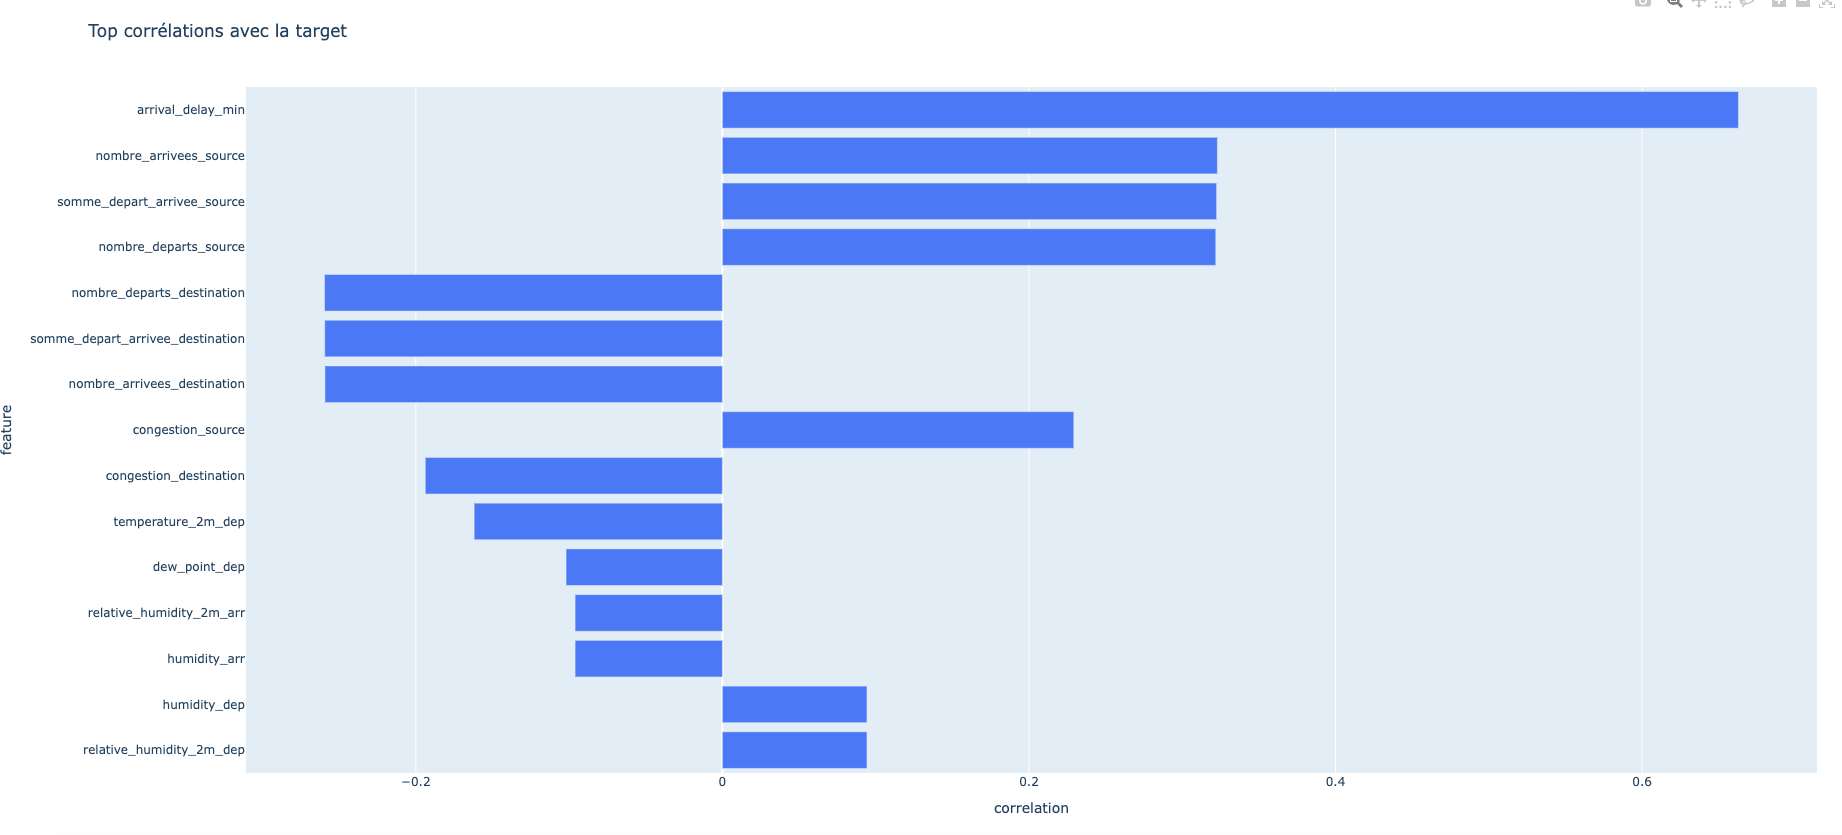

Celui-ci est corrigé : 

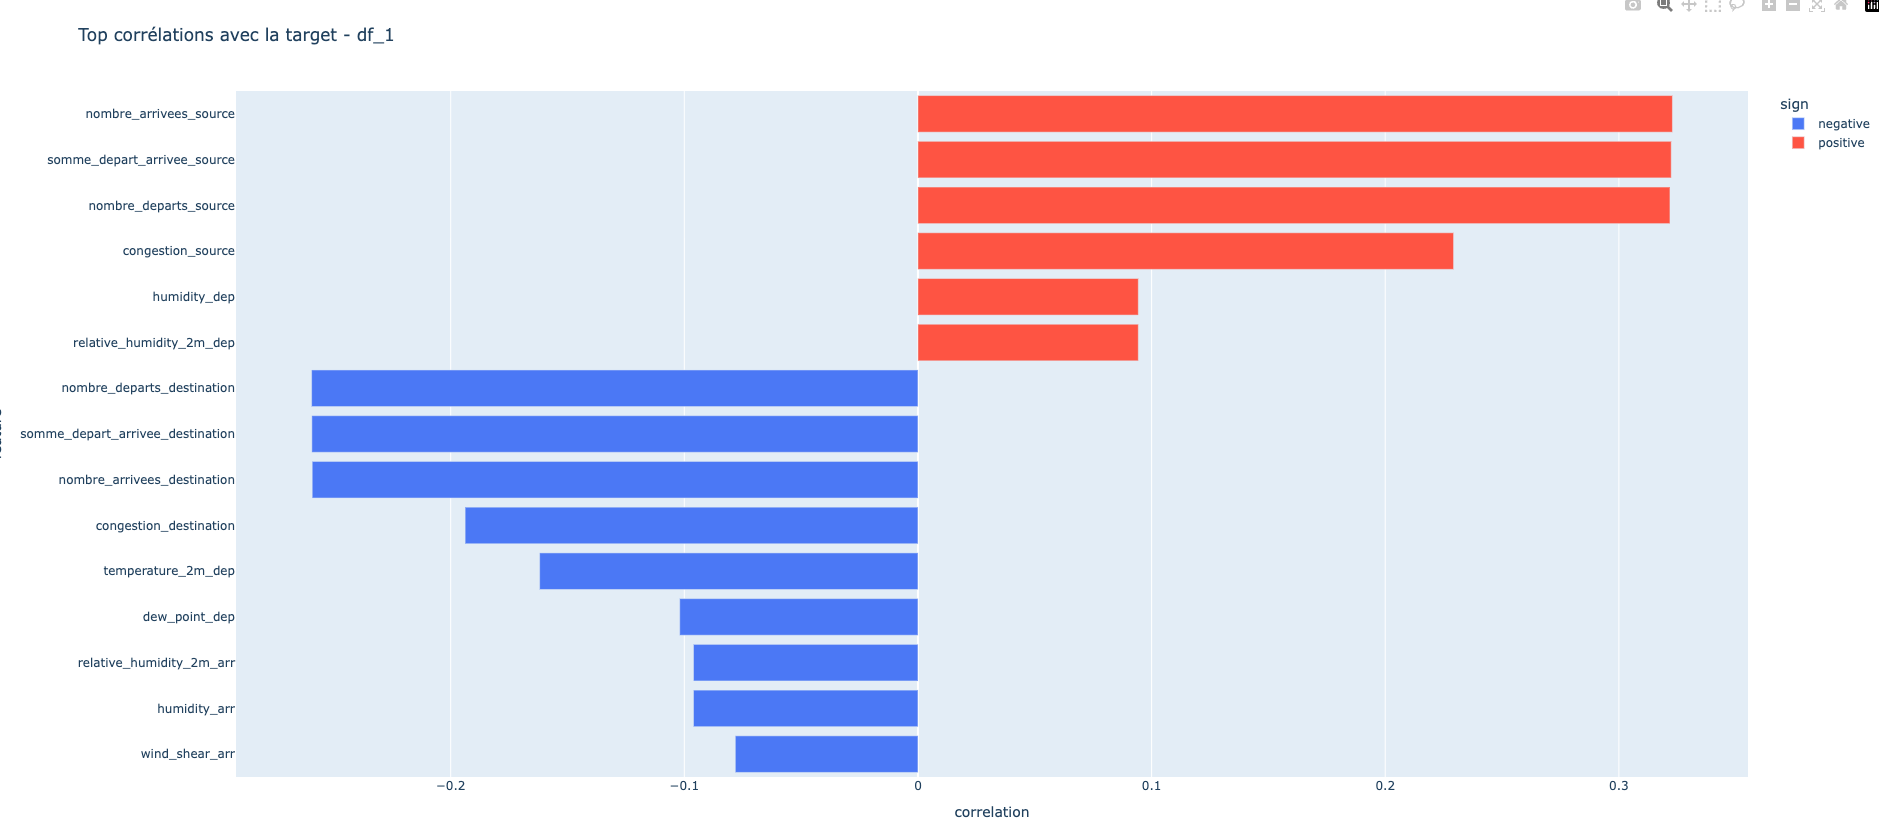

* **Top corrélations positives (retard ↑)**

  * `nombre_arrivees_source`, `somme_depart_arrivee_source`, `nombre_depart_source`, `congestion_source`
  * Interprétation : forte activité à l’aéroport de départ → plus de retards
  * Ce sont des variables très pertinentes métier (congestion)

* **Top corrélations négatives (retard ↓)**

  * `nombre_depart_destination`, `somme_depart_arrivee_destination`, `nombre_arrivees_destination`
  * Interprétation : l’état de l’aéroport d’arrivée influence aussi les retards
  * Effet inverse selon la fluidité ou la charge

* **Météo**

  * `humidity`, `temperature`, `dew_point`
  * Impact faible à modéré
  * Normal : facteur secondaire par rapport à la congestion

* **Point clé à retenir**

  * Corrélation ≠ importance modèle
  * RandomForest capture :

    * relations non linéaires
    * interactions entre variables
  * Donc :

    * une feature peu corrélée peut être importante
    * une feature très corrélée peut être moins utilisée

* **Conclusion**

  * Corrélation = signal simple
  * Importance modèle = impact réel
  * SHAP = explication fine du comportement
  * Voyons le SHAP


#### SHAP

In [22]:
import shap
import pandas as pd
import webbrowser
from pathlib import Path

X_sample_1 = X_test_1.sample(min(50, len(X_test_1)), random_state=42)

X_sample_1_preprocessed = model_1.named_steps["preprocessor"].transform(X_sample_1)
feature_names_1 = model_1.named_steps["preprocessor"].get_feature_names_out()

if hasattr(X_sample_1_preprocessed, "toarray"):
    X_sample_1_preprocessed = X_sample_1_preprocessed.toarray()

X_sample_1_preprocessed_df = pd.DataFrame(
    X_sample_1_preprocessed,
    columns=feature_names_1
).astype("float32")

rf_clf_1 = model_1.named_steps["classifier"]

explainer_1 = shap.TreeExplainer(rf_clf_1)
shap_values_1 = explainer_1.shap_values(X_sample_1_preprocessed_df)

shap.initjs()

if isinstance(shap_values_1, list):
    shap_plot = shap.force_plot(
        explainer_1.expected_value[1],
        shap_values_1[1],
        X_sample_1_preprocessed_df
    )
else:
    shap_plot = shap.force_plot(
        explainer_1.expected_value[1],
        shap_values_1[:, :, 1],
        X_sample_1_preprocessed_df
    )

output_file = Path("shap_force_plot_df1.html").resolve()
shap.save_html(str(output_file), shap_plot)

print(f"SHAP HTML saved to: {output_file}")

webbrowser.open(f"file://{output_file}")

SHAP HTML saved to: /Users/manjakaranjatoson/Desktop/A_I/JEDHA/PROJECTS/CDSD/PPML/code/01_ETL/Bronze/00_Manja_test/shap_force_plot_df1.html


True

Les variables liées à l’activité de l’aéroport source sont globalement positivement corrélées à la target, tandis que celles liées à la destination sont négativement corrélées.
Cependant, l’analyse SHAP révèle que l’impact de ces variables dépend fortement du contexte (interactions entre variables), ce qui montre que le modèle capture des relations non linéaires plus complexes que celles observées via la corrélation simple.

Nous allons donc essayer de trouver le meilleur des mondes (corrélations et shap) pour distinguer les features les plus importantes pour notre modèle et donc de notre problématique : PREDIRE LES RETARDS D'AVIONS A L'ARRIVEE

In [23]:
df_pred = pd.read_csv("/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PROJECTS/CDSD/PPML/data/processed/test_philippe/SignofFlightsDataset_72h_20260409_023452_CLEAN.csv")
df_pred.head()

,flight_date,movement_date,flight_number,airline,airport_origin,airport_destination,terminal_departure,terminal_arrival,scheduled_departure,scheduled_arrival,...,LABEL_ORLY,nombre_departs_source,nombre_arrivees_source,somme_depart_arrivee_source,congestion_source,nombre_departs_destination,nombre_arrivees_destination,somme_depart_arrivee_destination,congestion_destination,retard arrivée
0,DATE_GENERATION,2026-04-09 02:34:54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2026-04-08,2026-04-08,EC 4532,EasyJet Europe,NCE,CDG,2,2D,2026-04-08 21:55+02:00,2026-04-08 23:35+02:00,...,NaN,2.0,0.0,2.0,0.0,NaN,NaN,NaN,0.0,0.0
2,2026-04-08,2026-04-08,U2 4532,easyJet,NCE,CDG,2,2D,2026-04-08 21:55+02:00,2026-04-08 23:35+02:00,...,NaN,2.0,0.0,2.0,0.0,NaN,NaN,NaN,0.0,0.0
3,2026-04-09,2026-04-09,AF 7300,Air France,CDG,NCE,2F,2,2026-04-09 06:45+02:00,2026-04-09 08:15+02:00,...,NaN,2473.0,2502.0,4975.0,0.0,173.0,174.0,347.0,1.0,0.0
4,2026-04-09,2026-04-09,AF 7301,Air France,NCE,CDG,2,2F,2026-04-09 09:05+02:00,2026-04-09 10:40+02:00,...,NaN,173.0,174.0,347.0,1.0,2473.0,2502.0,4975.0,0.0,0.0


#### Top Influential Features df_1 (SHAP + Correlation)

##### 1. Corrélation complète

In [25]:
import pandas as pd
import numpy as np

# Copie propre
df_corr_full = X_1.copy()
df_corr_full["target"] = y_1.values

# Variables numériques uniquement
df_corr_full_num = df_corr_full.select_dtypes(include=["number"]).copy()

# Corrélation complète avec la target
corr_target_full = (
    df_corr_full_num.corr(numeric_only=True)["target"]
    .drop("target")
    .sort_values(key=np.abs, ascending=False)
)

corr_df_full = pd.DataFrame({
    "raw_feature": corr_target_full.index,
    "corr_with_target": corr_target_full.values
})

corr_df_full["abs_corr"] = corr_df_full["corr_with_target"].abs()
corr_df_full.head()

,raw_feature,corr_with_target,abs_corr
0,nombre_arrivees_source,0.322913,0.322913
1,somme_depart_arrivee_source,0.322413,0.322413
2,nombre_departs_source,0.321864,0.321864
3,nombre_departs_destination,-0.259524,0.259524
4,somme_depart_arrivee_destination,-0.259415,0.259415


##### 2. SHAP global léger

In [26]:
# Sample léger
X_shap_sample = X_test_1.sample(min(100, len(X_test_1)), random_state=42).copy()

# Préprocessing identique au modèle
X_shap_preprocessed = model_1.named_steps["preprocessor"].transform(X_shap_sample)
feature_names = model_1.named_steps["preprocessor"].get_feature_names_out()

if hasattr(X_shap_preprocessed, "toarray"):
    X_shap_preprocessed = X_shap_preprocessed.toarray()

X_shap_preprocessed_df = pd.DataFrame(
    X_shap_preprocessed,
    columns=feature_names
).astype("float32")

rf_clf = model_1.named_steps["classifier"]

explainer = shap.TreeExplainer(rf_clf)
shap_values = explainer.shap_values(X_shap_preprocessed_df)

##### 3. Extraction de l'importance de SHAP global

In [28]:
# Gestion binaire selon format retourné
if isinstance(shap_values, list):
    shap_array = shap_values[1]
else:
    shap_array = shap_values[:, :, 1]

# Importance globale = mean(|SHAP|)
shap_importance = np.abs(shap_array).mean(axis=0)

shap_df = pd.DataFrame({
    "encoded_feature": feature_names,
    "shap_importance": shap_importance
})

shap_df = shap_df.sort_values("shap_importance", ascending=False)
shap_df.head()

,encoded_feature,shap_importance
1282,cat__status_Departed,0.020439
33,num__nombre_departs_source,0.019113
39,num__somme_depart_arrivee_destination,0.018727
34,num__nombre_arrivees_source,0.017418
38,num__nombre_arrivees_destination,0.017356


##### 4. Regrouper par feature d’origine

In [29]:
def get_raw_feature_name(encoded_name: str) -> str:
    """
    Exemples :
    num__temperature -> temperature
    cat__airline_AF -> airline
    cat__status_delayed -> status
    """
    if encoded_name.startswith("num__"):
        return encoded_name.replace("num__", "")

    if encoded_name.startswith("cat__"):
        stripped = encoded_name.replace("cat__", "")
        parts = stripped.split("_")

        # on cherche le plus long préfixe qui existe dans X_1.columns
        for i in range(len(parts), 0, -1):
            candidate = "_".join(parts[:i])
            if candidate in X_1.columns:
                return candidate

        # fallback
        return parts[0]

    return encoded_name

In [30]:
shap_df["raw_feature"] = shap_df["encoded_feature"].apply(get_raw_feature_name)

shap_grouped_df = (
    shap_df.groupby("raw_feature", as_index=False)["shap_importance"]
    .sum()
    .sort_values("shap_importance", ascending=False)
)

shap_grouped_df.head(20)

,raw_feature,shap_importance
53,status,0.028814
14,airport_destination,0.028034
57,terminal_departure,0.026925
15,airport_origin,0.019535
56,terminal_arrival,0.019128
40,nombre_departs_source,0.019113
51,somme_depart_arrivee_destination,0.018727
38,nombre_arrivees_source,0.017418
37,nombre_arrivees_destination,0.017356
52,somme_depart_arrivee_source,0.017318


##### 5. Fusion corrélation + SHAP

In [31]:
final_df = pd.merge(
    corr_df_full[["raw_feature", "corr_with_target", "abs_corr"]],
    shap_grouped_df[["raw_feature", "shap_importance"]],
    on="raw_feature",
    how="outer"
).fillna(0)

# Normalisation min-max
def minmax(series):
    if series.max() == series.min():
        return pd.Series(0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())

final_df["corr_norm"] = minmax(final_df["abs_corr"])
final_df["shap_norm"] = minmax(final_df["shap_importance"])

# Score final : 70% SHAP, 30% corrélation
final_df["final_score"] = 0.3 * final_df["corr_norm"] + 0.7 * final_df["shap_norm"]

final_df = final_df.sort_values("final_score", ascending=False).reset_index(drop=True)

##### 6. Top 50 + top 20 conseillé

In [32]:
top_50_features = final_df.head(50).copy()
top_20_features = final_df.head(20).copy()

display(top_50_features)
display(top_20_features)

,raw_feature,corr_with_target,abs_corr,shap_importance,corr_norm,shap_norm,final_score
0,nombre_departs_source,0.321864,0.321864,0.019113,0.996752,0.662497,0.762774
1,nombre_arrivees_source,0.322913,0.322913,0.017418,1.000000,0.603522,0.722465
2,somme_depart_arrivee_source,0.322413,0.322413,0.017318,0.998450,0.600031,0.719557
3,status,0.000000,0.000000,0.028814,0.000000,1.000000,0.700000
4,somme_depart_arrivee_destination,-0.259415,0.259415,0.018727,0.803359,0.649056,0.695347
5,airport_destination,0.000000,0.000000,0.028034,0.000000,0.972883,0.681018
6,nombre_arrivees_destination,-0.259268,0.259268,0.017356,0.802902,0.601367,0.661828
7,terminal_departure,0.000000,0.000000,0.026925,0.000000,0.934287,0.654001
8,nombre_departs_destination,-0.259524,0.259524,0.016299,0.803697,0.564590,0.636322
9,airport_origin,0.000000,0.000000,0.019535,0.000000,0.677165,0.474015


,raw_feature,corr_with_target,abs_corr,shap_importance,corr_norm,shap_norm,final_score
0,nombre_departs_source,0.321864,0.321864,0.019113,0.996752,0.662497,0.762774
1,nombre_arrivees_source,0.322913,0.322913,0.017418,1.000000,0.603522,0.722465
2,somme_depart_arrivee_source,0.322413,0.322413,0.017318,0.998450,0.600031,0.719557
3,status,0.000000,0.000000,0.028814,0.000000,1.000000,0.700000
4,somme_depart_arrivee_destination,-0.259415,0.259415,0.018727,0.803359,0.649056,0.695347
5,airport_destination,0.000000,0.000000,0.028034,0.000000,0.972883,0.681018
6,nombre_arrivees_destination,-0.259268,0.259268,0.017356,0.802902,0.601367,0.661828
7,terminal_departure,0.000000,0.000000,0.026925,0.000000,0.934287,0.654001
8,nombre_departs_destination,-0.259524,0.259524,0.016299,0.803697,0.564590,0.636322
9,airport_origin,0.000000,0.000000,0.019535,0.000000,0.677165,0.474015


##### 7. Export CSV

In [33]:
top_50_features.to_csv("top_50_features_corr_shap.csv", index=False)
top_20_features.to_csv("top_20_features_corr_shap_recommande.csv", index=False)

print("CSV exportés")

CSV exportés


Je constate que la congestion des aéroports est le facteur principal des retards (nombre de départs/arrivées, somme trafic source/destination).

Je remarque aussi que certaines variables catégorielles (status, airport, terminal) sont très importantes pour le modèle, même si leur corrélation est nulle → preuve que SHAP apporte une vraie valeur.

La météo influence les retards, mais reste secondaire par rapport au trafic.

Il existe aussi un effet temporel (mois, jour de la semaine), mais moins fort.

Enfin, je reste prudent sur flight_number et status, qui peuvent capter des patterns trop spécifiques.

En résumé :
les retards sont surtout liés à la charge des aéroports + contexte opérationnel, puis la météo et le calendrier jouent un rôle complémentaire.

# Save the model

In [24]:
import joblib

# Sauvegarde du modèle complet (pipeline inclus)
joblib.dump(model_1, "model_retard_rf.joblib")

# Sauvegarde des colonnes d'entraînement (TRÈS IMPORTANT)
joblib.dump(X_1.columns.tolist(), "features_train.joblib")

print("Modèle et features sauvegardés")

Modèle et features sauvegardés


In [14]:
df_1.to_parquet(path="/Users/manjakaranjatoson/Desktop/A_I/JEDHA/PROJECTS/CDSD/PPML/code/01_ETL/Bronze/00_Manja_test/output/parquet/df_1.parquet")

In [15]:
df_1.columns

Index(['flight_date', 'movement_date', 'flight_number', 'airline',
       'airport_origin', 'airport_destination', 'terminal_departure',
       'terminal_arrival', 'scheduled_departure', 'scheduled_arrival',
       'arrival_delay_min', 'arrival_advance_min', 'status', 'movement_type',
       'time_dep', 'relative_humidity_2m_dep', 'dew_point_dep',
       'icing_conditions_dep', 'rain_dep', 'freezing_rain_dep', 'snow_dep',
       'thunderstorms_dep', 'pressure_msl_dep', 'wind_shear_dep',
       'wind_gusts_10m_dep', 'wind_speed_10m_dep', 'wind_direction_10m_dep',
       'precipitation_dep', 'has_precipitation_dep', 'fog_dep', 'humidity_dep',
       'temperature_2m_dep', 'cloud_cover_dep', 'time_arr',
       'relative_humidity_2m_arr', 'dew_point_arr', 'icing_conditions_arr',
       'rain_arr', 'freezing_rain_arr', 'snow_arr', 'thunderstorms_arr',
       'pressure_msl_arr', 'wind_shear_arr', 'wind_gusts_10m_arr',
       'wind_speed_10m_arr', 'wind_direction_10m_arr', 'precipitation_arr',

Compte rendu PPML - call Philippe x Manja 9/04 Aprem :
- Ajouter poids sur vacances vs jours fériés (voir cours) ou mettre poids dans les vacances (comme Noel plus que Paques / Vac de Février plus que Paques - à vérif avec LLM)
- Poid dans jours fériés même
- ~~Drop +66% et plus NaN values~~
- ~~Drop simplement duplicates 1426 lignes df_1 et un df_merged où on merge~~
- Voir corrélation features : retard départ et retard à l'arrivée -> MATRICE CORRELATION GAUSS (voir cours)